In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import 

In [61]:
datasets = ['QQQ']

df = yf.download(datasets, start='2010-01-01', end='2020-06-30')

# work only with close prices for all tickers
close = df['Close']

# percentage returns for each ticker
returns = close.pct_change()

features = pd.DataFrame(index=close.index)

# aggregate features across all datasets
features['volatility'] = returns.rolling(window=50).std().mean(axis=1)
features['momentum'] = (returns.rolling(window=50).mean() / returns.rolling(window=50).std().replace(0, np.nan)).mean(axis=1)
features['skewness'] = returns.rolling(window=50).skew().mean(axis=1)
features['avg_return'] = returns.rolling(window=50).mean().mean(axis=1)

features = features.dropna()


print(features.head())


[*********************100%***********************]  1 of 1 completed

            volatility  momentum  skewness  avg_return
Date                                                  
2010-03-17    0.010778  0.054640 -1.120430    0.000589
2010-03-18    0.010785  0.060830 -1.137430    0.000656
2010-03-19    0.010785  0.060797 -1.137303    0.000656
2010-03-22    0.010850  0.075924 -1.155476    0.000824
2010-03-23    0.010833  0.073562 -1.156261    0.000797


In [62]:
#normalize features before clustering

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [63]:
#use PCA to reduce dimensionality for visualization
pca = PCA(n_components=3).fit_transform(scaled_features)

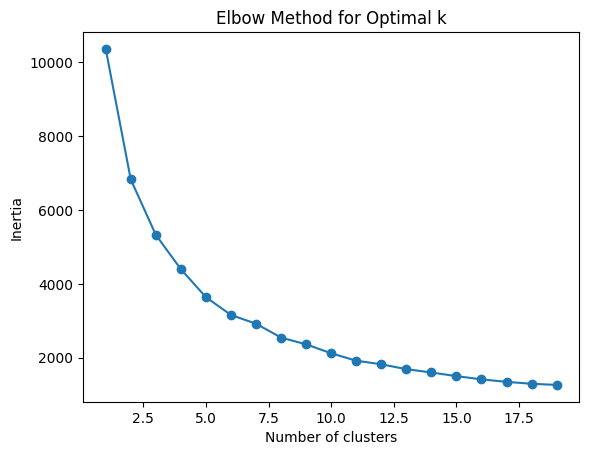

In [64]:
# Run an elbow method to find optimal number of clusters
inertia = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 20), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

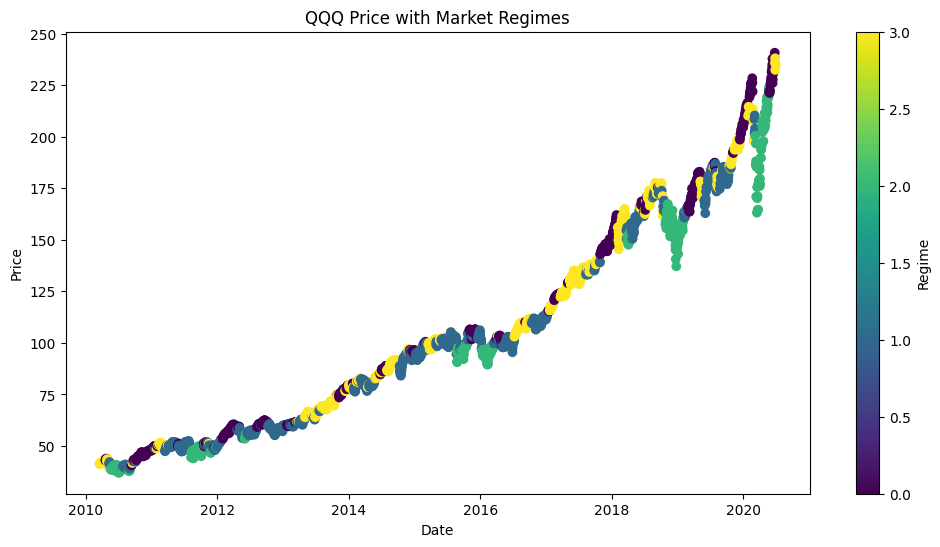

In [66]:
# run k-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
regime = kmeans.fit_predict(scaled_features)

# plot regimes
plt.figure(figsize=(12, 6))
plt.scatter(features.index, close.loc[features.index, 'QQQ'], c=regime, cmap='viridis', marker='o')
plt.title('QQQ Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.colorbar(label='Regime')
plt.show()

In [67]:
#calc silhouette score

sil_score = silhouette_score(scaled_features, regime)
print(f"\nSilhouette Score: {sil_score:.2f}")


Silhouette Score: 0.27
